In [1]:
import pandas as pd
import soundscapy as sspy
import warnings

warnings.filterwarnings("ignore")

# Read in the data
circumplex_file = "/Volumes/ritd-ag-project-rd01wq-tober63/SSID IVR Study 1/2024-08-29_14-20_circumplex_data.xlsx"
a_df = pd.read_excel(circumplex_file, sheet_name="A")
av_df = pd.read_excel(circumplex_file, sheet_name="AV")
v_df = pd.read_excel(circumplex_file, sheet_name="V")

paq_aliases = {
    "Pleasant": "PAQ1",
    "Vibrant": "PAQ2",
    "Eventful": "PAQ3",
    "Chaotic": "PAQ4",
    "Annoying": "PAQ5",
    "Monotonous": "PAQ6",
    "Uneventful": "PAQ7",
    "Calm": "PAQ8",
}

In [2]:
a_df["Experiment"] = "Audio"
av_df["Experiment"] = "Audio-Visual"
v_df["Experiment"] = "Visual"

df = pd.concat([a_df, av_df, v_df])
df = df.rename(columns=paq_aliases)
df, excl_df = sspy.isd.validate(df, val_range=(-50, 50))


In [3]:
df

,Participant,trial,response_id,started,finished,PAQ1,PAQ4,PAQ2,PAQ7,PAQ8,...,4V,response,SessionID,ISOPleasant,ISOEventful,Experiment,Unnamed: 42,`,finshed,fineshed
0,P4,0,11.0,NaN,NaN,33,-37,5,7,34,...,NaN,NaN,RiverLeeSchools1b,0.571335,-0.155233,Audio,NaN,NaN,NaN,NaN
1,P4,1,10.0,NaN,NaN,-20,-9,-32,3,12,...,NaN,NaN,WineOfficeCt1,-0.295894,-0.207660,Audio,NaN,NaN,NaN,NaN
2,P4,2,12.0,NaN,NaN,50,-50,27,26,37,...,NaN,NaN,RegentsParkJapan2,0.894558,-0.012721,Audio,NaN,NaN,NaN,NaN
3,P4,3,13.0,NaN,NaN,14,24,11,-38,-25,...,NaN,NaN,ZhongshanPark5,-0.048162,0.429411,Audio,NaN,NaN,NaN,NaN
4,P4,4,17.0,NaN,NaN,5,11,45,-39,-9,...,NaN,NaN,LianhuashanParkEntrance1,0.381213,0.668198,Audio,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1154,P38,25,69.0,27/04/2023 10:54:30,27/04/2023 10:55:10,50,-20,21,-28,27,...,NaN,NaN,CarloV2,0.759828,0.298112,Visual,NaN,NaN,NaN,NaN
1155,P38,26,68.0,27/04/2023 10:52:57,27/04/2023 10:53:51,50,-50,20,8,50,...,NaN,NaN,RegentsParkJapan2,0.912132,-0.199706,Visual,NaN,NaN,NaN,NaN
1156,P38,27,83.0,27/04/2023 11:11:19,27/04/2023 11:11:50,13,-21,-24,11,-13,...,NaN,NaN,RiverLeeSchools1b,0.161457,-0.220919,Visual,NaN,NaN,NaN,NaN
1157,P38,28,81.0,27/04/2023 11:08:42,27/04/2023 11:09:25,-50,15,-38,22,-50,...,NaN,NaN,StephensonSt1,-0.711213,-0.164767,Visual,NaN,NaN,NaN,NaN


## P48 Analysis

In [4]:
p48_data = df.query("Participant == 'P48' and Experiment == 'Audio-Visual'")
p48_data = p48_data.query(
    "SessionID in ['CamdenTown4', 'NewRiverWalk1', 'TateModern3']"
)
p48_data.reset_index(drop=True, inplace=True)
p48_data

,Participant,trial,response_id,started,finished,PAQ1,PAQ4,PAQ2,PAQ7,PAQ8,...,4V,response,SessionID,ISOPleasant,ISOEventful,Experiment,Unnamed: 42,`,finshed,fineshed
0,P48,12,3.0,05/09/2023 16:07:49,05/09/2023 16:08:36,-50,49,5,-50,-50,...,NaN,NaN,CamdenTown4,-0.528234,0.859411,Audio-Visual,NaN,NaN,NaN,NaN
1,P48,15,5.0,05/09/2023 16:10:34,05/09/2023 16:11:12,34,6,26,-44,-37,...,NaN,NaN,TateModern3,0.373173,0.691335,Audio-Visual,NaN,NaN,NaN,NaN
2,P48,16,4.0,05/09/2023 16:09:06,05/09/2023 16:09:52,37,-50,-48,41,31,...,NaN,NaN,NewRiverWalk1,0.498112,-0.634975,Audio-Visual,NaN,NaN,NaN,NaN


(<Figure size 640x480 with 1 Axes>, <PolarAxes: >)

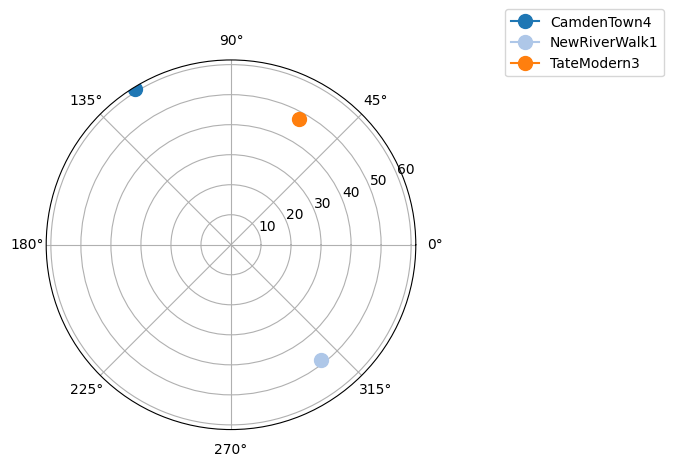

In [15]:
import circumplex

p48_res = circumplex.ssm_analyse(
    p48_data,
    scales=["PAQ1", "PAQ2", "PAQ3", "PAQ4", "PAQ5", "PAQ6", "PAQ7", "PAQ8"],
    grouping="SessionID",
)
p48_res.plot()

(<Figure size 800x1200 with 3 Axes>,
 array([<Axes: title={'center': 'CamdenTown4 Profile'}, xlabel='Angle [deg]', ylabel='Score'>,
        <Axes: title={'center': 'NewRiverWalk1 Profile'}, xlabel='Angle [deg]', ylabel='Score'>,
        <Axes: title={'center': 'TateModern3 Profile'}, xlabel='Angle [deg]', ylabel='Score'>],
       dtype=object))

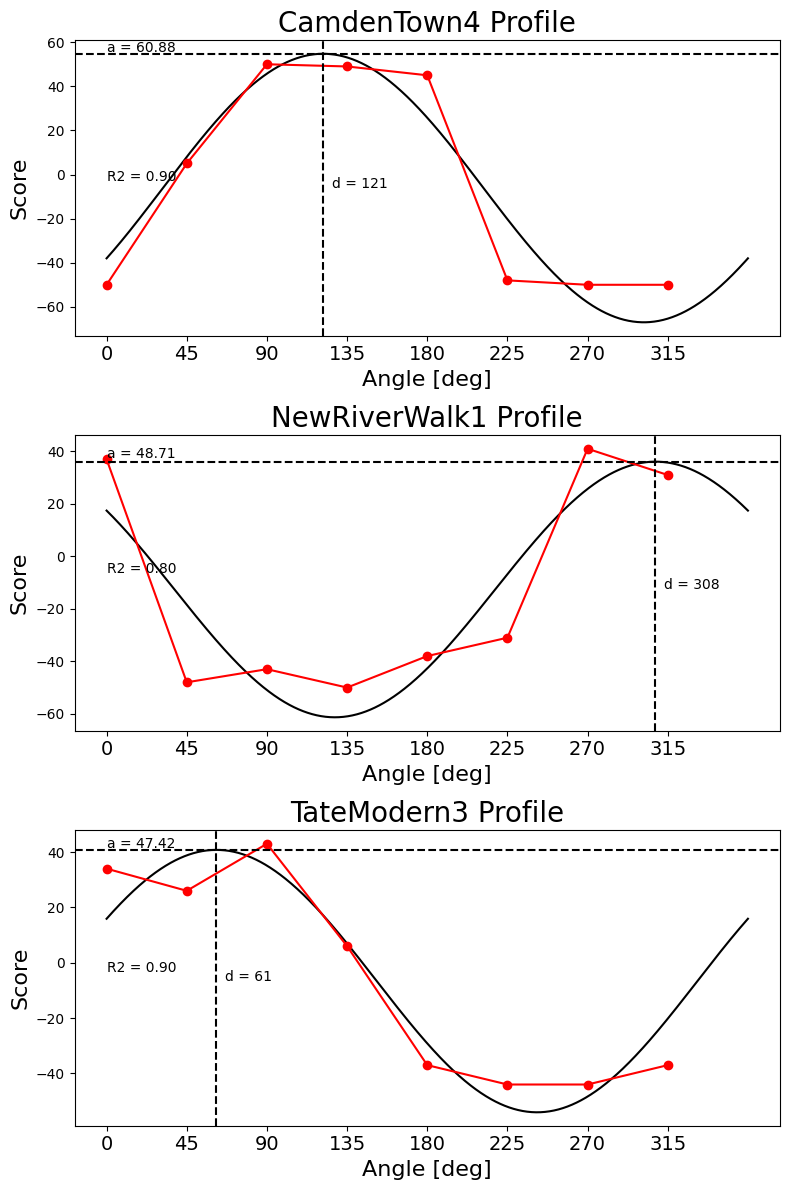

In [16]:
p48_res.profile_plots()

<Axes: title={'center': 'Assessment of three locations\n by one participant'}, xlabel='ISOPleasant', ylabel='ISOEventful'>

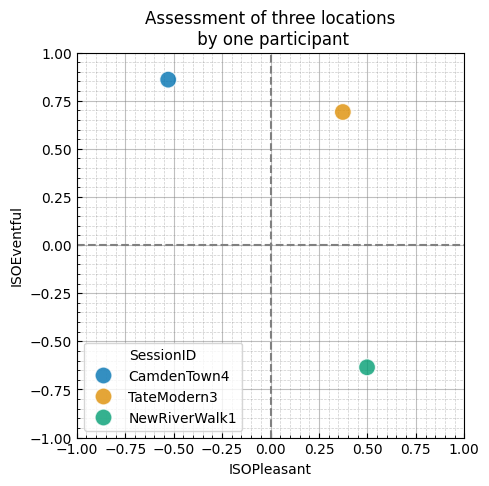

In [ ]:
sspy.plotting.scatter_plot(
    p48_data,
    hue="SessionID",
    title="Assessment of three locations\n by one participant",
    s=150,
)